In [43]:
#Author: Angel Diaz-Nova, Ricardo Hernandez, Nataliia Padilla
%pip install pandas requests textblob wordcloud newsapi haversine tabulate selenium
#TODO: VSCode requires the use of % instead of !. This should be changed back before submission.
#CHANGE: Added Haversine for my portion. Haversine is a package used to measure distance between coordinates.
import requests #downloads zip file from webpage
import pandas as pd
import matplotlib.pyplot as plt
import zipfile #extracts csv from zip
import io #allows treat downloaded data as a file object
import seaborn as sns
import time#allows for the program to pause to avoid API rate limits
from textblob import TextBlob # will be used to analyse news from the internet
#TODO: This line does not work in VSCode, might work in Colab. Should check before submitting.
#New code from  https://github.com/mattlisiv/newsapi-python/issues/5#issuecomment-448281100
#from newsapi import NewsApiClient # will be used to extract latests articles
#from newsapi.newsapi_client import NewsApiClient # will be used to extract latests articles (Replaces previous line)
from wordcloud import WordCloud # to create a word cloud of words mostly used in the articles
from haversine import haversine, Unit #to measure distance between Capital Bikeshare stations and public transit stations
from tabulate import tabulate #Used to print table

# New Code
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.keys import Keys
from webdriver_manager.chrome import ChromeDriverManager

Note: you may need to restart the kernel to use updated packages.


In [7]:
#Author: Nataliia Padilla
web = [#'https://s3.amazonaws.com/capitalbikeshare-data/2010-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2011-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2012-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2013-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2014-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2015-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2016-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/2017-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201801-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201802-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201803-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201804-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201805-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201806-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201807-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201808-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201809-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201810-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201811-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201812-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201901-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201902-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201903-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201904-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201905-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201906-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201907-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201908-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201907-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201908-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201909-capitalbikeshare-tripdata.zip',
      #'https://s3.amazonaws.com/capitalbikeshare-data/201910-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201911-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/201912-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/202001-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/202002-capitalbikeshare-tripdata.zip',
       #'https://s3.amazonaws.com/capitalbikeshare-data/202003-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202005-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202006-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202007-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202008-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202009-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202010-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202011-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202012-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202101-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202102-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202103-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202104-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202105-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202106-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202107-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202108-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202109-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202110-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202111-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202112-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202201-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202202-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202203-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202204-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202205-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202206-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202207-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202208-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202209-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202210-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202211-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202212-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202301-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202302-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202303-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202304-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202305-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202306-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202307-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202308-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202309-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202310-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202311-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202312-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202401-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202402-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202403-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202404-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202405-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202406-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202407-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202408-capitalbikeshare-tripdata.zip',
       'https://s3.amazonaws.com/capitalbikeshare-data/202409-capitalbikeshare-tripdata.zip']
#commented first files that didn't have the same set of columns
df_list = [] #adding each file as a dataframe to a list

In [13]:
#Author: Nataliia Padilla
#This cell might take a while, you're downloading 16million lines of data
#Just let the program do it's thing and ensure you have sufficient memory available
for url in web:
    response = requests.get(url) #downloaded zip file from web
    if response.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file: #extracting the data
            for filename in zip_file.namelist():
                #if filename.endwith('.csv'):
                with zip_file.open(filename) as f:
                    df_1 = pd.read_csv(f, encoding='ISO-8859-1', low_memory=False) # there was some error in the columns (missmatch of value types)
                    df_list.append(df_1)
    else:
        print(f'Failed to download the ZIP file from {url} . Status code ', response.status_code)
df = pd.concat(df_list, ignore_index = True)
#print(df)
#idk what those last columns are about, probably can just delete
df = df.drop(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2'], axis=1)

In [14]:
#Author: Ricardo Hernandez, Nataliia Padilla
#Convert 'started_at' and 'ended_at' to datetime
df['started_at'] = pd.to_datetime(df['started_at'], format='ISO8601')
df['ended_at'] = pd.to_datetime(df['ended_at'], format='ISO8601')

#Calculate additional columns
#TODO: Check if anyone is using these columns before we submit. If no one is using them, removing would be best
#for memory savings
df['Time Start'] = df['started_at'].dt.time
df['Time End'] = df['ended_at'].dt.time
df['Year'] = df['started_at'].dt.year
df['Month'] = df['started_at'].dt.month 
df['Day Started'] = df['started_at'].dt.day_name()

#Calculate ride length
df['Ride Length'] = df['ended_at'] - df['started_at']
df['Ride Length_min'] = pd.to_timedelta(df['Ride Length']).dt.seconds/60

#Calculate if during the ride time a fine was incurred
df['Fine'] = df['Ride Length_min'] > 30 # Rides over 30 minutes incur a fine

In [15]:
df.head() # Testing to see if new column appears and indicates the right logic

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,Time Start,Time End,Year,Month,Day Started,Ride Length,Ride Length_min,Fine
0,946D42AD89539210,docked_bike,2020-05-30 17:25:29,2020-05-31 18:25:22,Anacostia Library,31804,11th & H St NE,31614.0,38.865784,-76.978400,...,-76.991383,casual,17:25:29,18:25:22,2020.0,5.0,Saturday,1 days 00:59:53,59.883333,True
1,CC46FAAB662B8613,docked_bike,2020-05-09 14:42:04,2020-05-09 15:06:33,10th & E St NW,31256,21st St & Constitution Ave NW,31261.0,38.895914,-77.026064,...,-77.046567,member,14:42:04,15:06:33,2020.0,5.0,Saturday,0 days 00:24:29,24.483333,False
2,72F00B2FB833D6ED,docked_bike,2020-05-24 17:27:19,2020-05-24 17:43:51,Connecticut Ave & Newark St NW / Cleveland Park,31305,12th & U St NW,31268.0,38.934267,-77.057979,...,-77.028139,member,17:27:19,17:43:51,2020.0,5.0,Sunday,0 days 00:16:32,16.533333,False
3,4DFBE6AED989DF35,docked_bike,2020-05-27 15:29:52,2020-05-27 15:47:13,Connecticut Ave & Newark St NW / Cleveland Park,31305,14th & Belmont St NW,31119.0,38.934267,-77.057979,...,-77.031887,casual,15:29:52,15:47:13,2020.0,5.0,Wednesday,0 days 00:17:21,17.350000,False
4,1AAFE6B4331AB9DF,docked_bike,2020-05-31 14:06:03,2020-05-31 14:30:30,Georgia Ave & Morton St NW,31419,17th & K St NW,31213.0,38.932128,-77.023500,...,-77.038630,casual,14:06:03,14:30:30,2020.0,5.0,Sunday,0 days 00:24:27,24.450000,False


## Exploring Inferential Questions Using Capital Bikeshare

# Angel Diaz-Nova

Overview:

1) Supporting awareness of fees based on ride time

   - How many riders have incurred a fee because exceeding the time limit?
   - Can riders like 'Members' advocate for an increased time limit?
  
2) Providing clarity from the Bereau of Transportation Statistics 

   -  What graphs indicate which forms of commute are more common within our area?
   -  Are the Bereau actively supporting the use of micromobility as a form of commute?

## First Section

# Awareness of Fees 

For logistic reasons, any user who'd like to cycle say to work, will have to be weary of paying a fee. This is based on the time limit that is exerted for every ride. 

In [19]:
# Angel Diaz-Nova
Total_fines = df['Fine'].sum()
print(f"Total Incurred Fines: {Total_fines}")

Fines_user = df[df['Fine']].groupby('member_casual')['Fine'].count()
print("Breadown Based On User Status:")
print(Fines_user.to_frame(name = "Number of Fines").reset_index().to_string(index = False))

Total Incurred Fines: 2205768
Breadown Based On User Status:
member_casual  Number of Fines
       casual          1588988
       member           616780


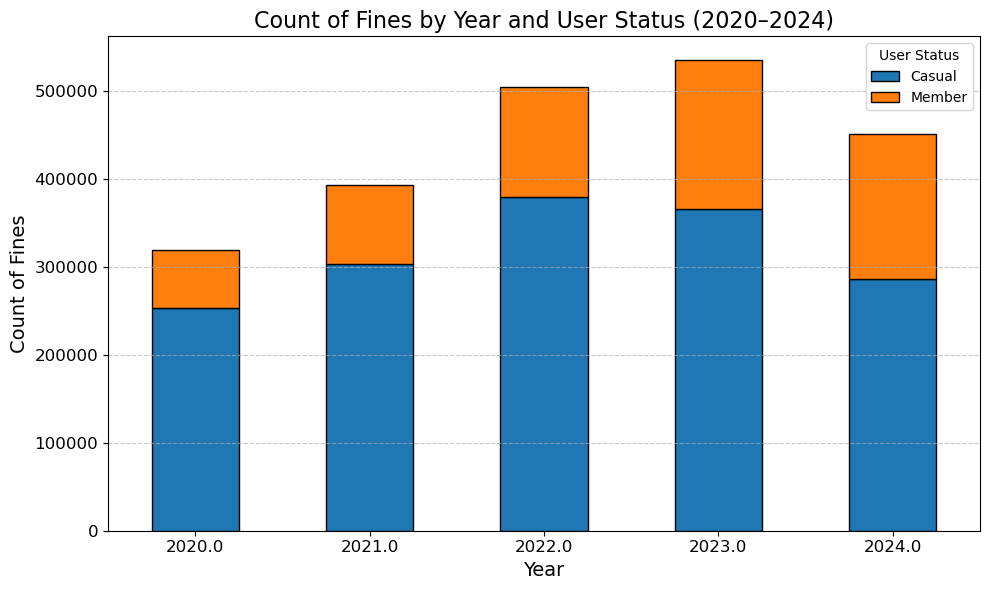

In [20]:
# Angel Diaz-Nova
Yes_fine = df[df['Fine']] # Filter for rows that only indicate 'True' logic

# Count fines by year and member_casual
Group_fine = Yes_fine.groupby(['Year', 'member_casual']).size().unstack(fill_value=0)

Group_fine.plot(
    kind = 'bar', # Setting to Bar Plot
    stacked = True, # Adjusting to stack bars to differentiate User Status 
    figsize = (10, 6), # Setting figure size
    color = ['#1f77b4', '#ff7f0e'],  # Colors for casual and member
    edgecolor = 'black' # Adding black edges
)

plt.title('Count of Fines by Year and User Status (2020–2024)', fontsize = 16) # Title of plot
plt.xlabel('Year', fontsize = 14) # Label for X-axis
plt.ylabel('Count of Fines', fontsize = 14) # Label for Y-Axis
plt.legend(title = 'User Status', labels = ['Casual', 'Member']) # Legend to describe the user status
plt.xticks(rotation = 0, fontsize = 12) # # Adjusting font size and adding rotation of X-Axis label
plt.yticks(fontsize = 12) # Adjusting font size of Y-Axis label
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7) # Adding a horizontal grid

# Show the plot
plt.tight_layout() # Adding a tight layout to ensure no overlapping
plt.show() # Display Plot

Q: How many riders, members or casuals alike pay a fine? Meaning the bike ride exceeded the 30 minute time limit. Also, is there a difference between both groups? 

A: As predicted beforehand, casual riders are more 'prone' to incurred fees/fines. There have been over 2,205,768 labelled as 'True,' meaning over 2 million reported rides have led to am incurred fine due to exceeding the time limit of 30 minutes. More specifically, as the amount of rides grew over the years, so did the the count of fines - seen very profoundly, but with a slight decrease from 2023 to 2024. But, this can change given the year is still yet to end. 

Following that up what if the context was reversed. Within the confines of this thinking, is it possible to configure a simple, yet perhaps complex contrast to the past question. But this time advocate a new policy or arrangement for a certain group?

In [23]:
# Angel Diaz-Nova
No_fine = len(df) - Total_fines 
print(f"Rides With No Incurred Fine: {No_fine}")

No_fines_user = df[df['Fine'] == False].groupby('member_casual')['Fine'].count()

# Print the breakdown based on user status (member/casual)
print("Breakdown Based on User Status (No Fines):")
print(No_fines_user.to_frame(name = "Number of Rides Without Fine").reset_index().to_string(index = False))

Rides With No Incurred Fine: 14545754
Breakdown Based on User Status (No Fines):
member_casual  Number of Rides Without Fine
       casual                       4934135
       member                       9611610


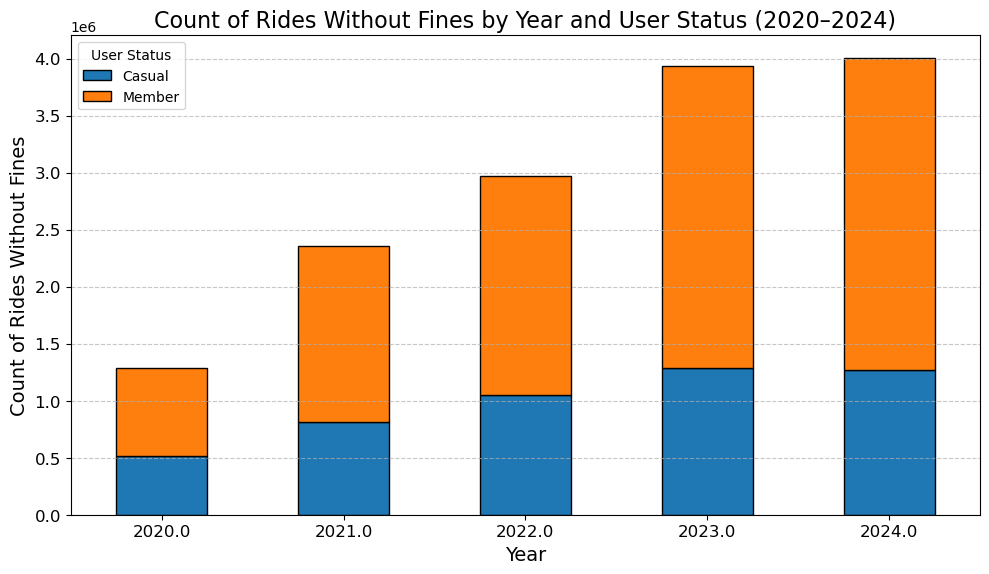

In [24]:
# Angel Diaz-Nova
No_fine = df[df['Fine'] == False] # Filter for rows that only indicate 'False' logic

# Count 'False' cases by year and member_casual
Group_no_fine = No_fine.groupby(['Year', 'member_casual']).size().unstack(fill_value=0)

Group_no_fine.plot(
    kind = 'bar',  # Setting to Bar plot
    stacked = True,  # Adjusting to stack bars to differentiate User Status
    figsize = (10, 6),  # Setting figure size
    color = ['#1f77b4', '#ff7f0e'], # Colors for casual and member 
    edgecolor = 'black' # Adding black edges
)

plt.title('Count of Rides Without Fines by Year and User Status (2020–2024)', fontsize=16) # Title of plot
plt.xlabel('Year', fontsize = 14) # Label for X-Axis
plt.ylabel('Count of Rides Without Fines', fontsize = 14) # Label for Y-Axis
plt.legend(title = 'User Status', labels = ['Casual', 'Member']) # Legend to describe the user status
plt.xticks(rotation = 0, fontsize = 12) # Adjusting font size and adding rotation of X-Axis label
plt.yticks(fontsize = 12) # Adjusting font size of Y-Axis label
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7) # Adding a horizontal grid

# Show the plot
plt.tight_layout() # Adding a tight layout to ensure no overlaps
plt.show() # Display plot

Q: Similar concept as before with a twist. A small trend was shown previously that rides are increasing over the past four years. Can the inverse of before provide a baseline to advocate for members to earn an extended time limit? 

A: For the sake of argument, the same inferences can be made with the graph and simple count statistic. However, based on the Bereau's message, they are actively showing effort to improve upon their existing policies and programs to the betterment of all Americans who rely on connected transportation networks. To clarify, a clear trend is shown throughout the last four years, that riders with 'Member' status are less likely to incur a fee during their ride. My suggestion would be to include a feature where members are given an extended time limit.

## Second Section

# Clarity from Berearu of Transportation Statistics

Furthermore, as seen through Ricardo's work, District of Colombia is known to have a higher percentage of overall riders than its nearing regions. For example, the suburbs of Maryland, or the suburbs of Virginia. To add more context, scraping content from the Bereau of Statistics can help to explain this in more depth.

C:\Users\Angel\anaconda3\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Scraping BTS webpage...
Scraped 0 items from the BTS webpage.



Enter a search query (or type 'exit' to quit):  Capital Bikeshare


KeyError: 'Title'

Q: What forms of commute are most common in the District of Colombia? What is the case for the nearing regions that are close by to D.C.? -> Add incentive and more information to provide clarity

A:

In [63]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time

In [65]:
driver = webdriver.Chrome(executable_path='path_to_chromedriver')

TypeError: WebDriver.__init__() got an unexpected keyword argument 'executable_path'

In addition from before, the Bereau of Transportation Statistics webpage includes a series coined 'Cycling and Scooting Through the Years' where BTS report ground breaking analysis on a macro-level (Country wide) to study transportation networks in order to efficiently assist with creating policies and programs around transportation equity and affordability. 

Q: To consider all forms of commute, has BTS made significant efforts to support types of micromobility? In other words, those who wish to travel very light, as in e-scooters, e-bikes, and so forth. ->  

A: 